# Toy Delayed Feedback Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

rows = []
for name in ['README.md','requirements.txt','reproduce_fast.py','reproduce_full.py','reproduce_paper.py','code_check.py','self_check.py','output_manifest.md','docs','outputs','runlogs']:
    rows.append({'path': name, 'exists': (ROOT/name).exists()})
display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if not row['exists'] and row['path'] in {'README.md','outputs'}]
if missing:
    display(Markdown('Warning: required display/interface paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub display paths are present.'))


,path,exists
0,README.md,True
1,requirements.txt,True
2,reproduce_fast.py,True
3,reproduce_full.py,True
4,reproduce_paper.py,True
5,code_check.py,True
6,self_check.py,True
7,output_manifest.md,True
8,docs,False
9,outputs,True


Required GitHub display paths are present.

In [2]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

csvs = prefer_outputs(find_files(['outputs/**/summaries/*.csv','outputs/**/summary/*.csv','outputs/**/tables/*.csv','outputs/**/checks/*.csv','outputs/**/metadata/*.csv']))
display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)


Found `6` CSV/table/check/metadata files. Showing selected previews.

**outputs/full/summary/toy_method_summary.csv**

,experiment_id,mode,config_hash,delay_setting,method,n_seeds,mean_final_Rc,std_final_Rc,se_final_Rc,ci95_low,ci95_high,mean_gain_vs_naive_pct,gain_ci95_low,gain_ci95_high
0,toy,full,d58591a6ee,0_delay,causal_labelled,30,284.658876,42.087883,7.684161,269.597920,299.719831,0.000000,0.000000,0.000000
1,toy,full,d58591a6ee,0_delay,naive,30,284.658876,42.087883,7.684161,269.597920,299.719831,NaN,NaN,NaN
2,toy,full,d58591a6ee,0_delay,oracle,30,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
3,toy,full,d58591a6ee,geom_0.15,causal_labelled,30,370.933023,57.862556,10.564209,350.227173,391.638873,41.375665,38.052786,44.698545
4,toy,full,d58591a6ee,geom_0.15,naive,30,636.508466,68.256187,12.461818,612.083303,660.933629,NaN,NaN,NaN
5,toy,full,d58591a6ee,geom_0.15,oracle,30,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
6,toy,full,d58591a6ee,mixed_geom_0.6+0.1_w0.2,causal_labelled,30,371.078859,54.327748,9.918844,351.637924,390.519794,37.616147,34.207559,41.024735
7,toy,full,d58591a6ee,mixed_geom_0.6+0.1_w0.2,naive,30,601.904172,93.510168,17.072543,568.441988,635.366356,NaN,NaN,NaN


Rows: `12` | Columns: `14`

**outputs/full/summary/toy_seed_summary.csv**

...

,experiment_id,mode,config_hash,run_id,seed,delay_setting,method,T,K,D_max,...,source_state_distance_mean,source_state_distance_sum,source_state_distance_p90,final_Rc,normalized_final_Rc,auc_causal_regret,mean_instant_causal_regret,gain_vs_naive,gain_vs_naive_pct,runtime_seconds
0,toy,fast,13b5551d55,toy_fast_13b5551d55_0_delay_oracle_s000,0,0_delay,oracle,2000,5,10,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.059172
1,toy,fast,13b5551d55,toy_fast_13b5551d55_0_delay_naive_s000,0,0_delay,naive,2000,5,10,...,0.000000,0.000000,0.000000,341.905435,0.170953,155.709673,0.170953,NaN,NaN,0.027728
2,toy,fast,13b5551d55,toy_fast_13b5551d55_0_delay_causal_labelled_s000,0,0_delay,causal_labelled,2000,5,10,...,0.000000,0.000000,0.000000,341.905435,0.170953,155.709673,0.170953,0.000000,0.000000,0.024258
3,toy,fast,13b5551d55,toy_fast_13b5551d55_geom_0.15_oracle_s000,0,geom_0.15,oracle,2000,5,10,...,0.153418,244.241095,0.339687,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.020207
4,toy,fast,13b5551d55,toy_fast_13b5551d55_geom_0.15_naive_s000,0,geom_0.15,naive,2000,5,10,...,0.153418,244.241095,0.339687,742.550318,0.371275,333.294107,0.371275,NaN,NaN,0.027785
5,toy,fast,13b5551d55,toy_fast_13b5551d55_geom_0.15_causal_labelled_...,0,geom_0.15,causal_labelled,2000,5,10,...,0.153418,244.241095,0.339687,405.981202,0.202991,185.480873,0.202991,336.569116,45.326102,0.025627
6,toy,fast,13b5551d55,toy_fast_13b5551d55_piece_0.6to0.15_oracle_s000,0,piece_0.6to0.15,oracle,2000,5,10,...,0.122159,217.932254,0.273986,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.022528
7,toy,fast,13b5551d55,toy_fast_13b5551d55_piece_0.6to0.15_naive_s000,0,piece_0.6to0.15,naive,2000,5,10,...,0.122159,217.932254,0.273986,601.914716,0.300957,313.982916,0.300957,NaN,NaN,0.025462


Rows: `36` | Columns: `27`

**outputs/fast/summary/toy_trajectory_summary.csv**

,experiment_id,mode,config_hash,delay_setting,method,t,mean_cumulative_Rc,se_cumulative_Rc,ci95_low,ci95_high
0,toy,fast,13b5551d55,0_delay,causal_labelled,1,0.500000,0.250000,0.010000,0.990000
1,toy,fast,13b5551d55,0_delay,causal_labelled,2,1.270959,0.027231,1.217587,1.324331
2,toy,fast,13b5551d55,0_delay,causal_labelled,3,1.648356,0.292237,1.075571,2.221141
3,toy,fast,13b5551d55,0_delay,causal_labelled,4,2.031276,0.294501,1.454054,2.608497
4,toy,fast,13b5551d55,0_delay,causal_labelled,5,2.674433,0.191776,2.298552,3.050313
5,toy,fast,13b5551d55,0_delay,causal_labelled,6,2.674433,0.191776,2.298552,3.050313
6,toy,fast,13b5551d55,0_delay,causal_labelled,7,2.674433,0.191776,2.298552,3.050313
7,toy,fast,13b5551d55,0_delay,causal_labelled,8,2.674433,0.191776,2.298552,3.050313


Rows: `24000` | Columns: `10`

Found `4` PNG figure files. Showing selected embedded figures.

**outputs/full/figures/toy_full_trajectories.png**

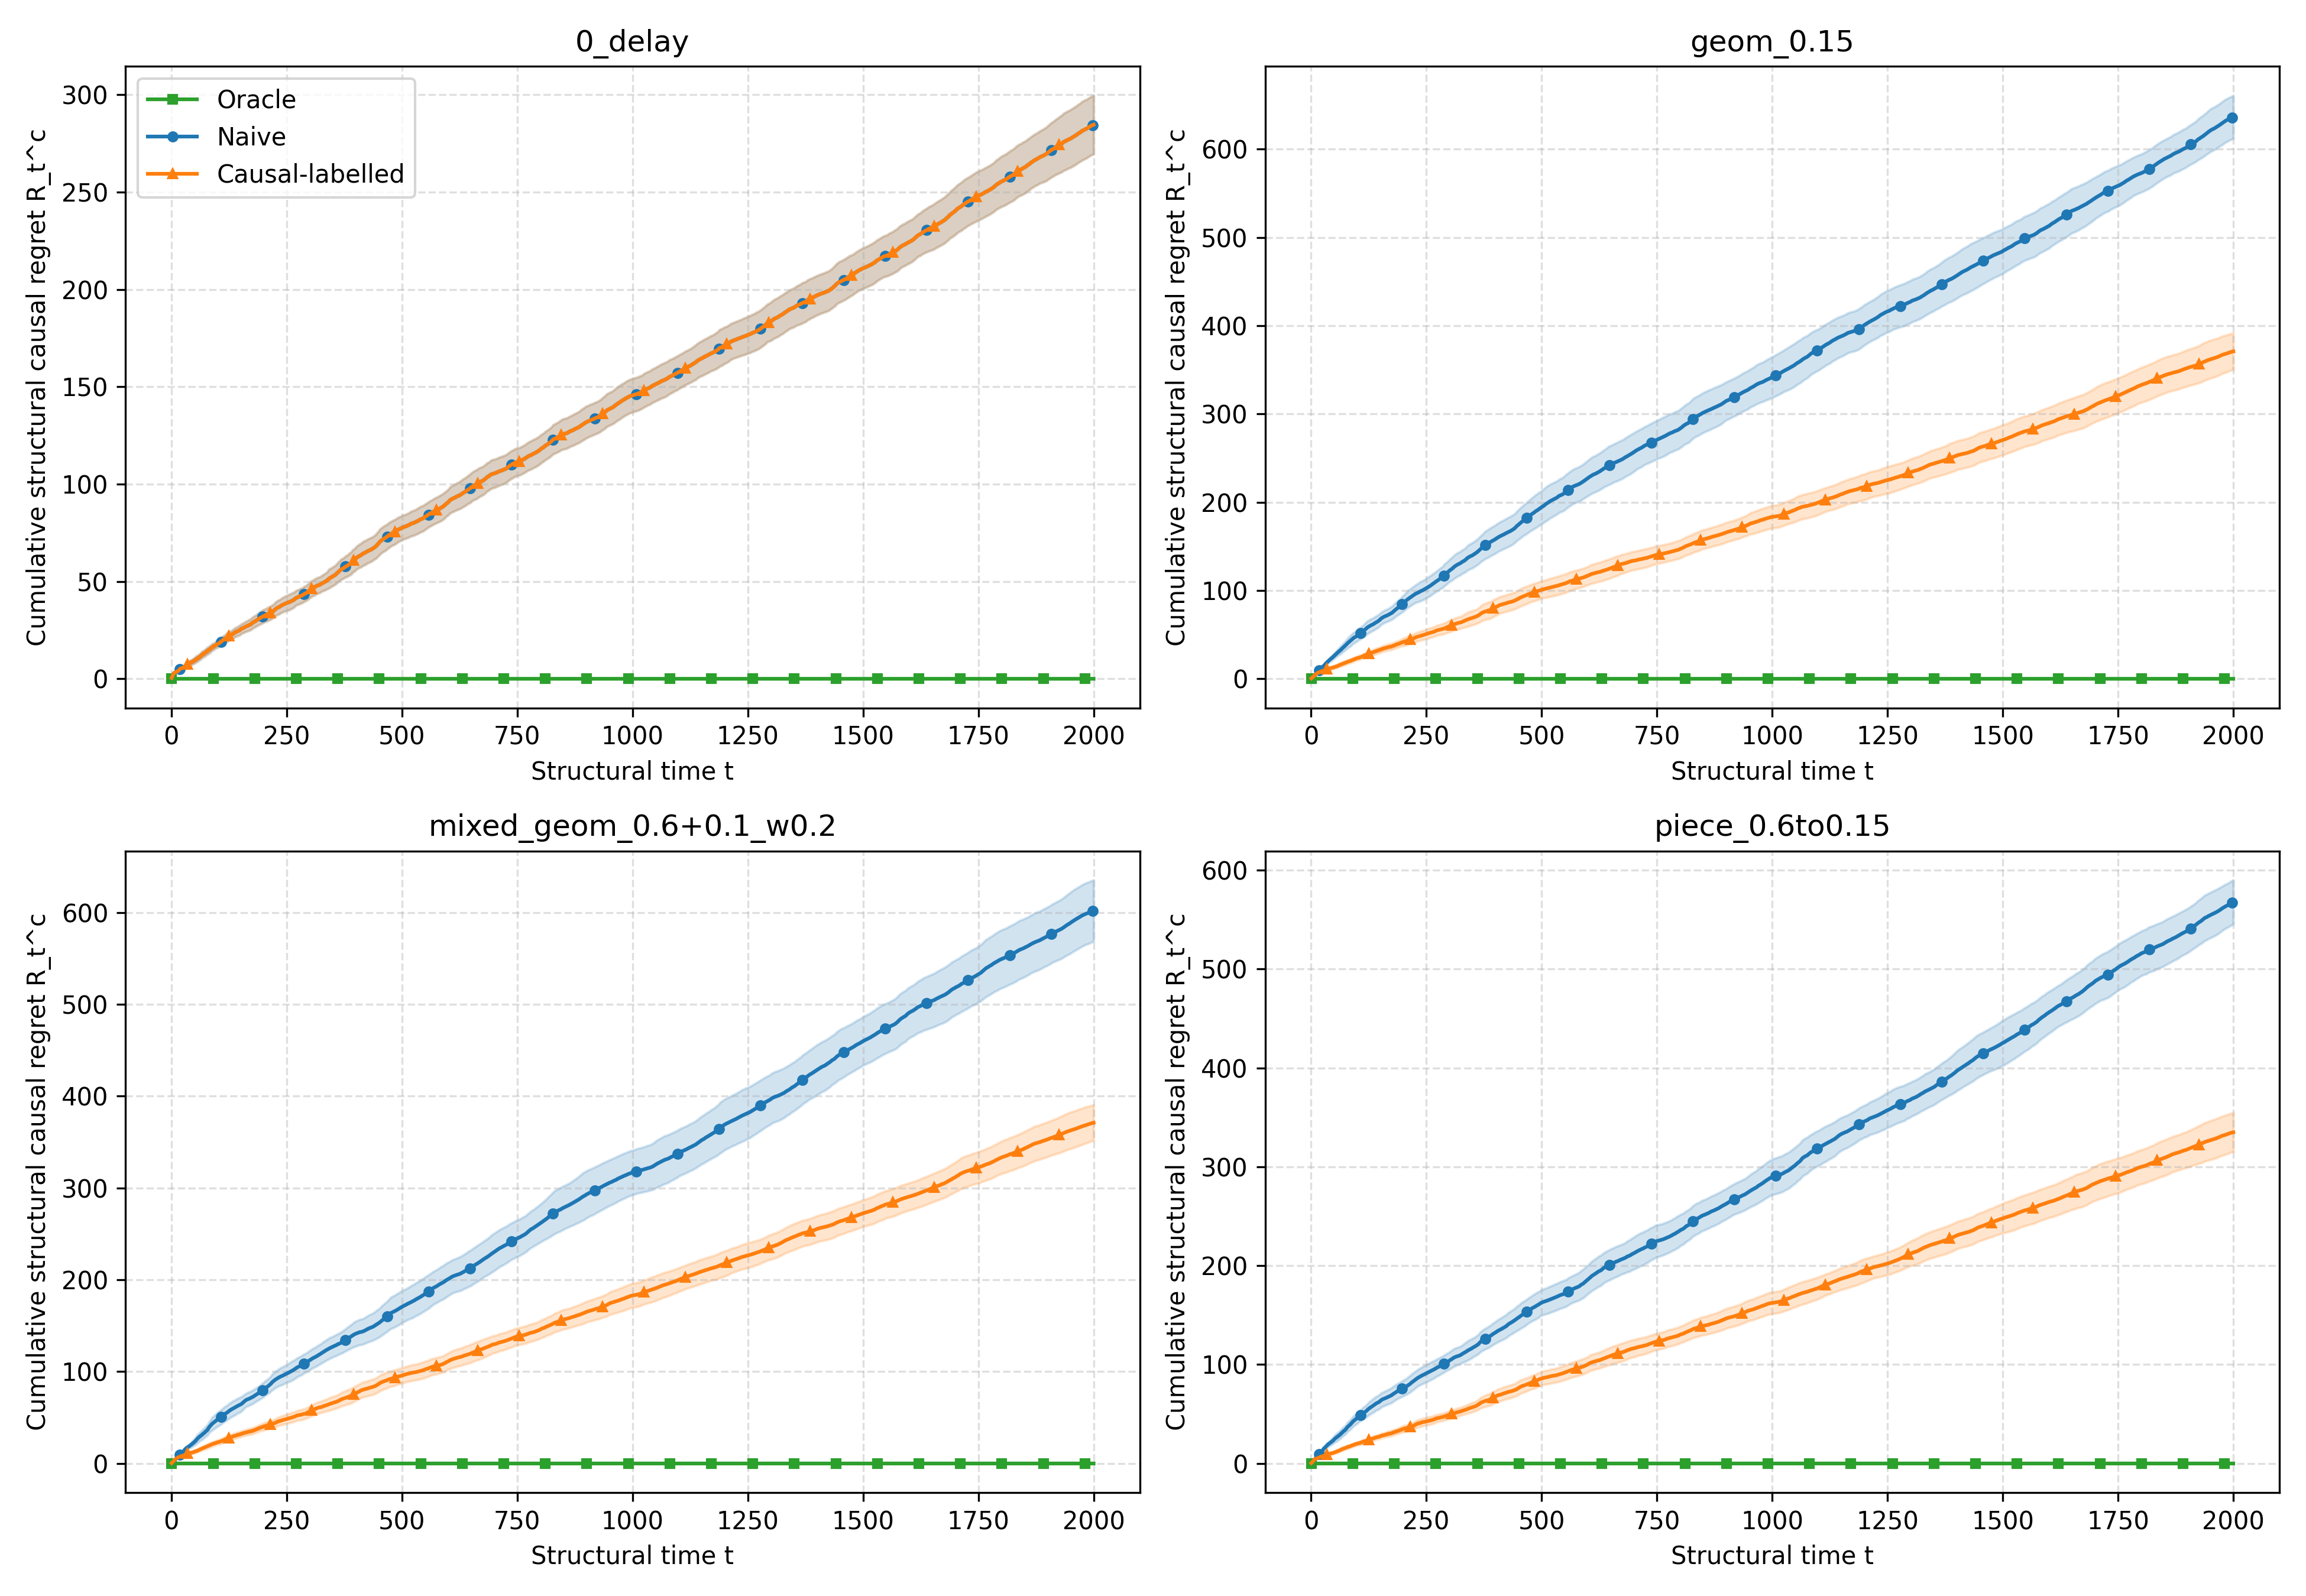

**outputs/full/figures/toy_selected_trajectories.png**

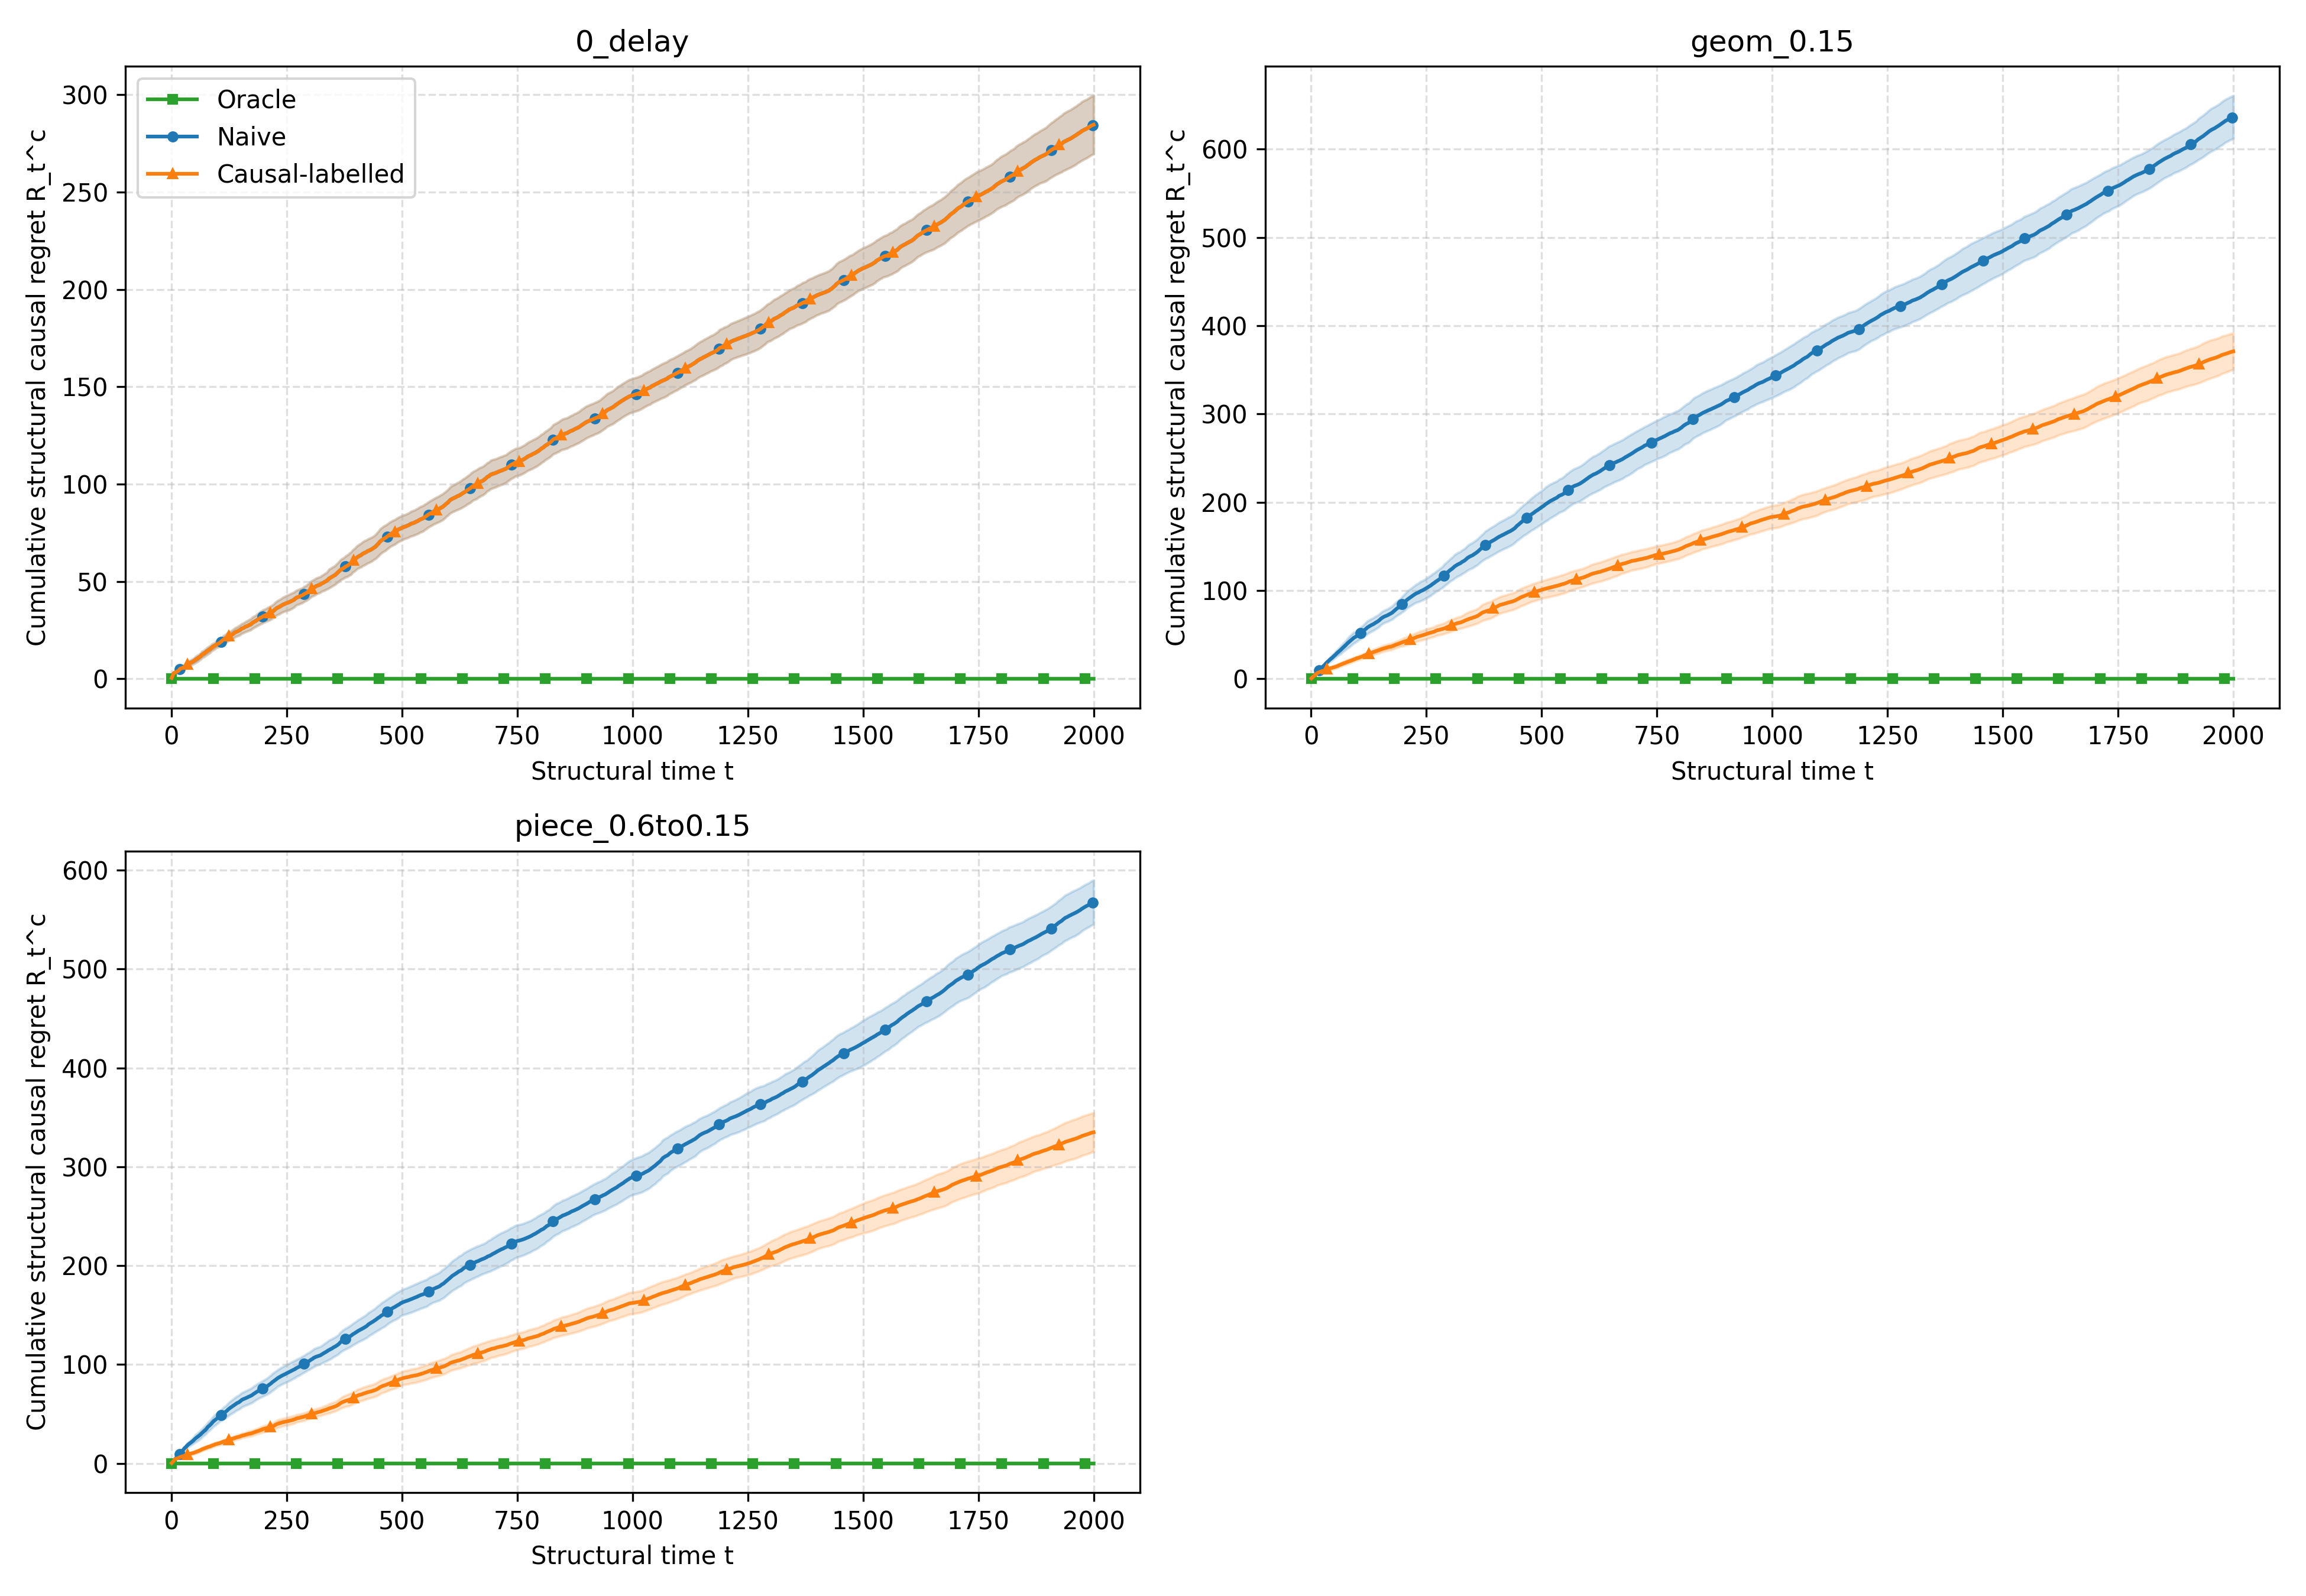

**outputs/fast/figures/toy_full_trajectories.png**

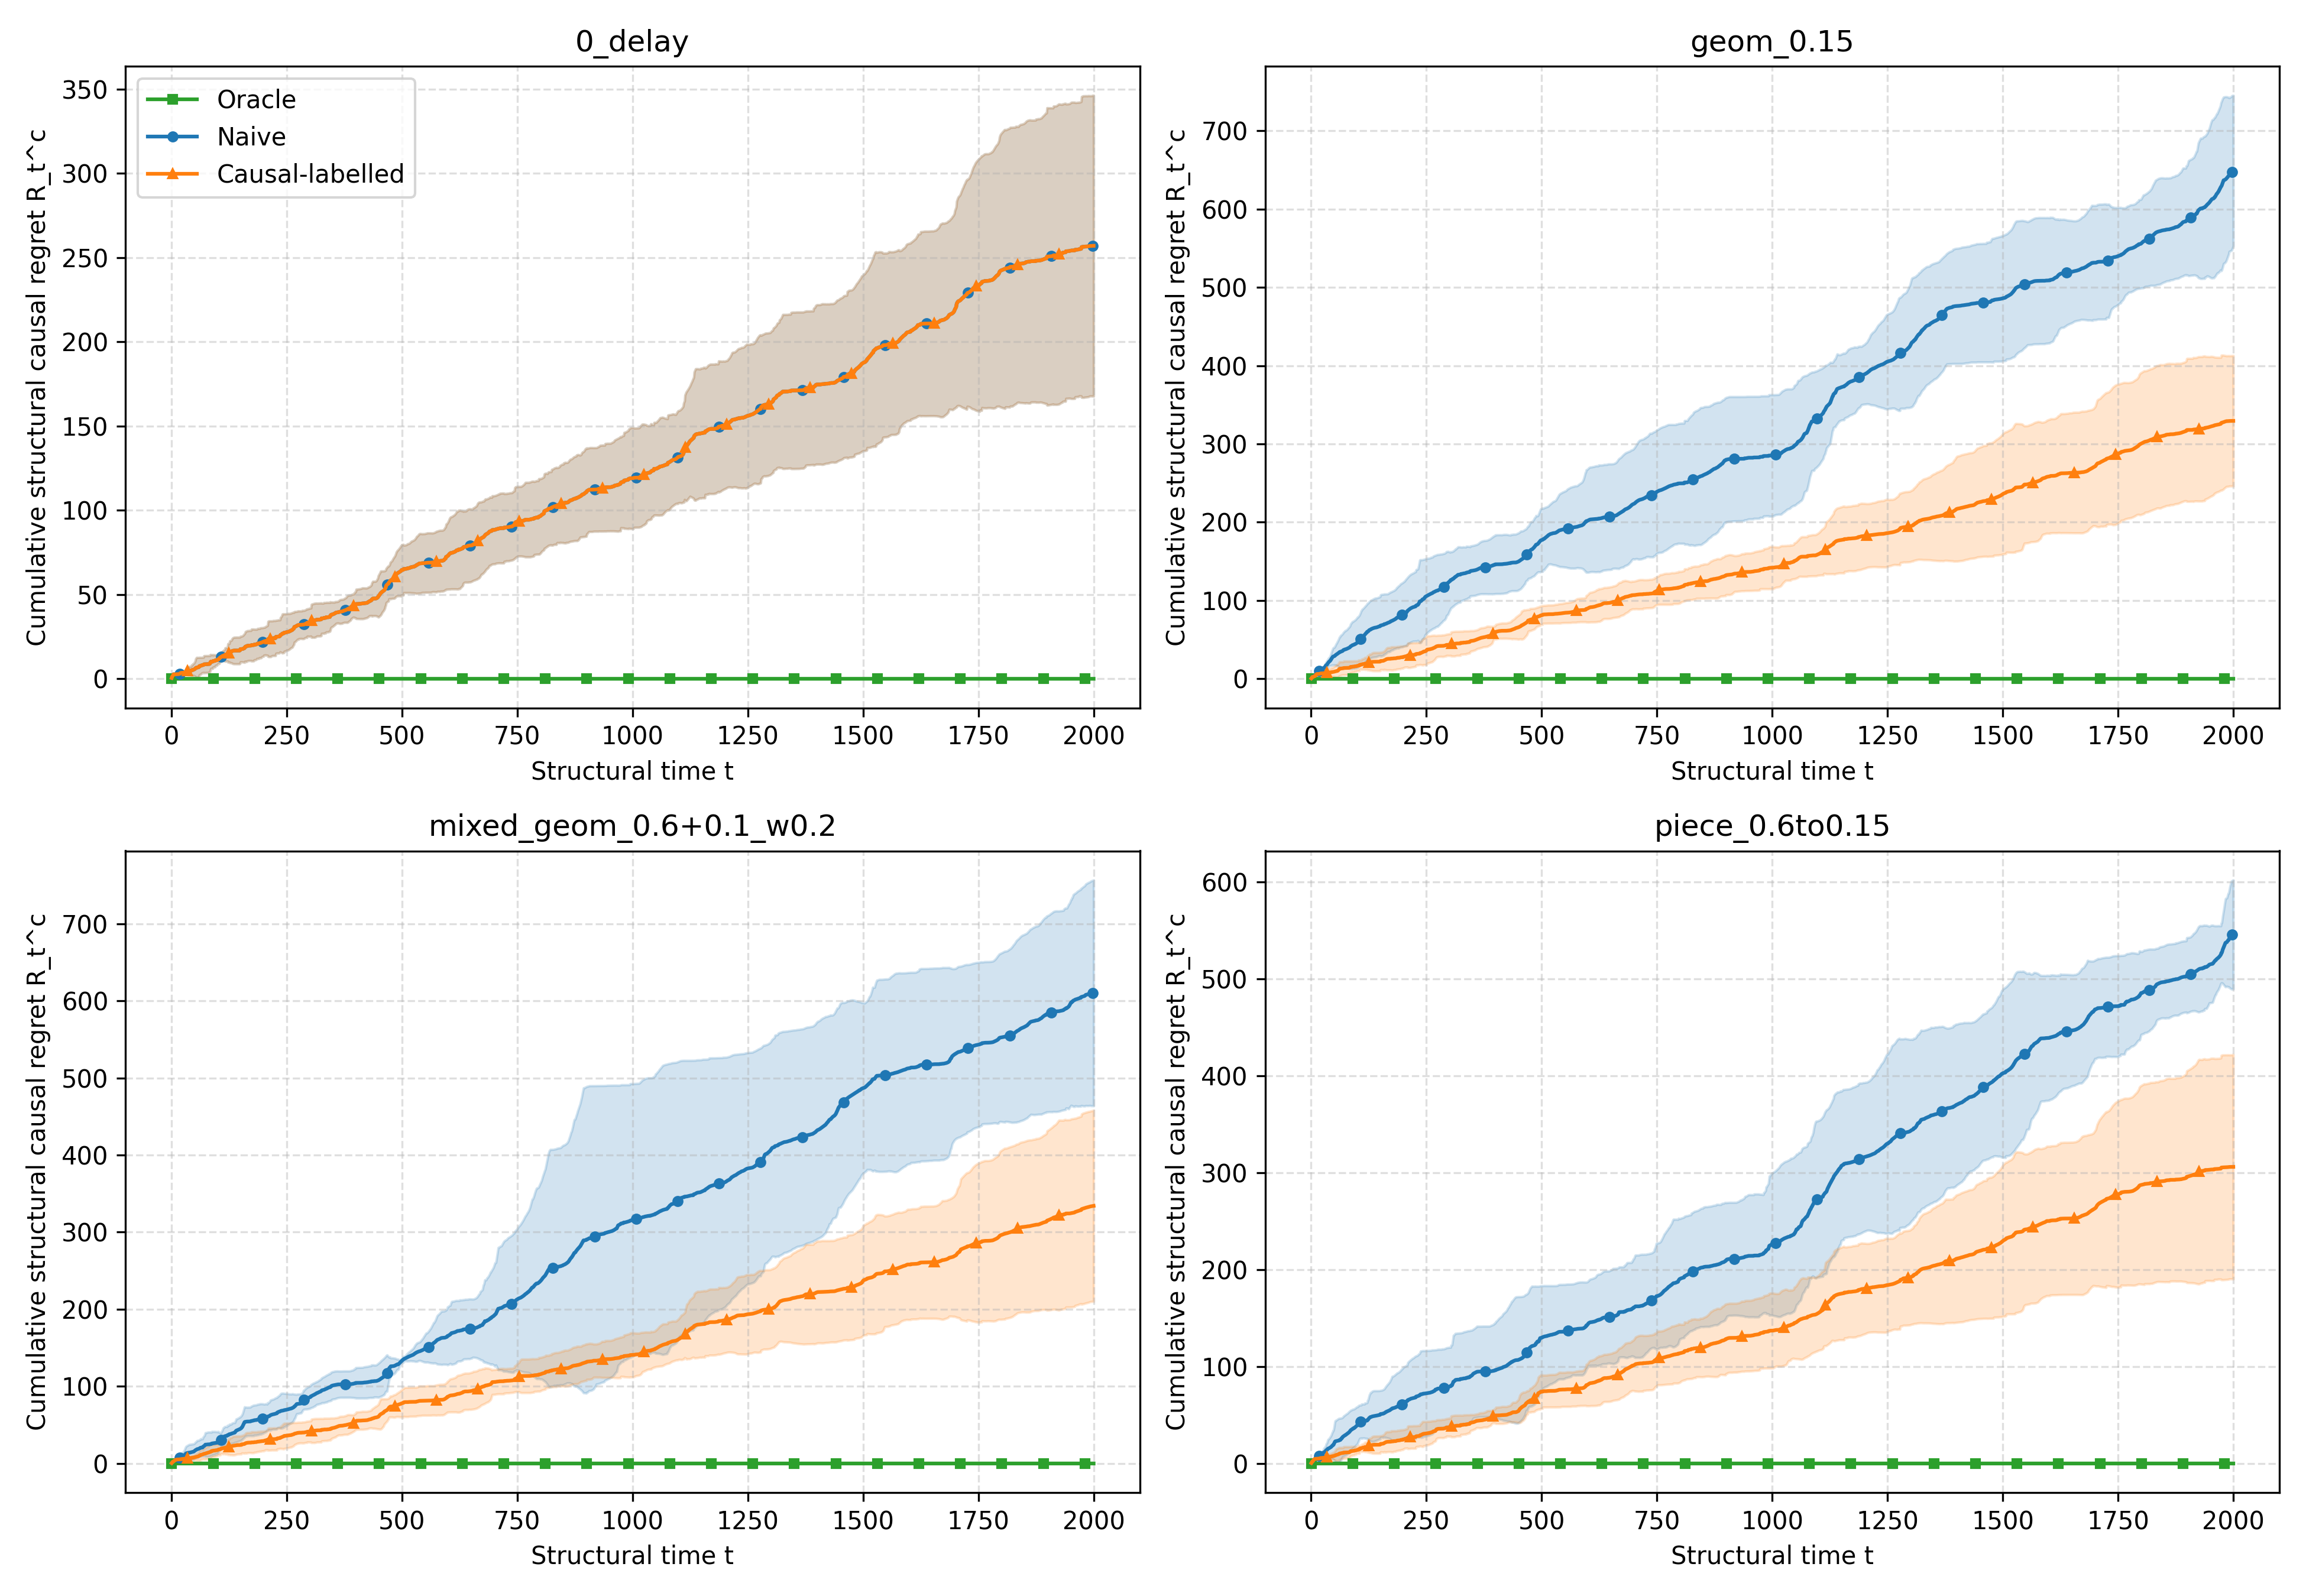

**outputs/fast/figures/toy_selected_trajectories.png**

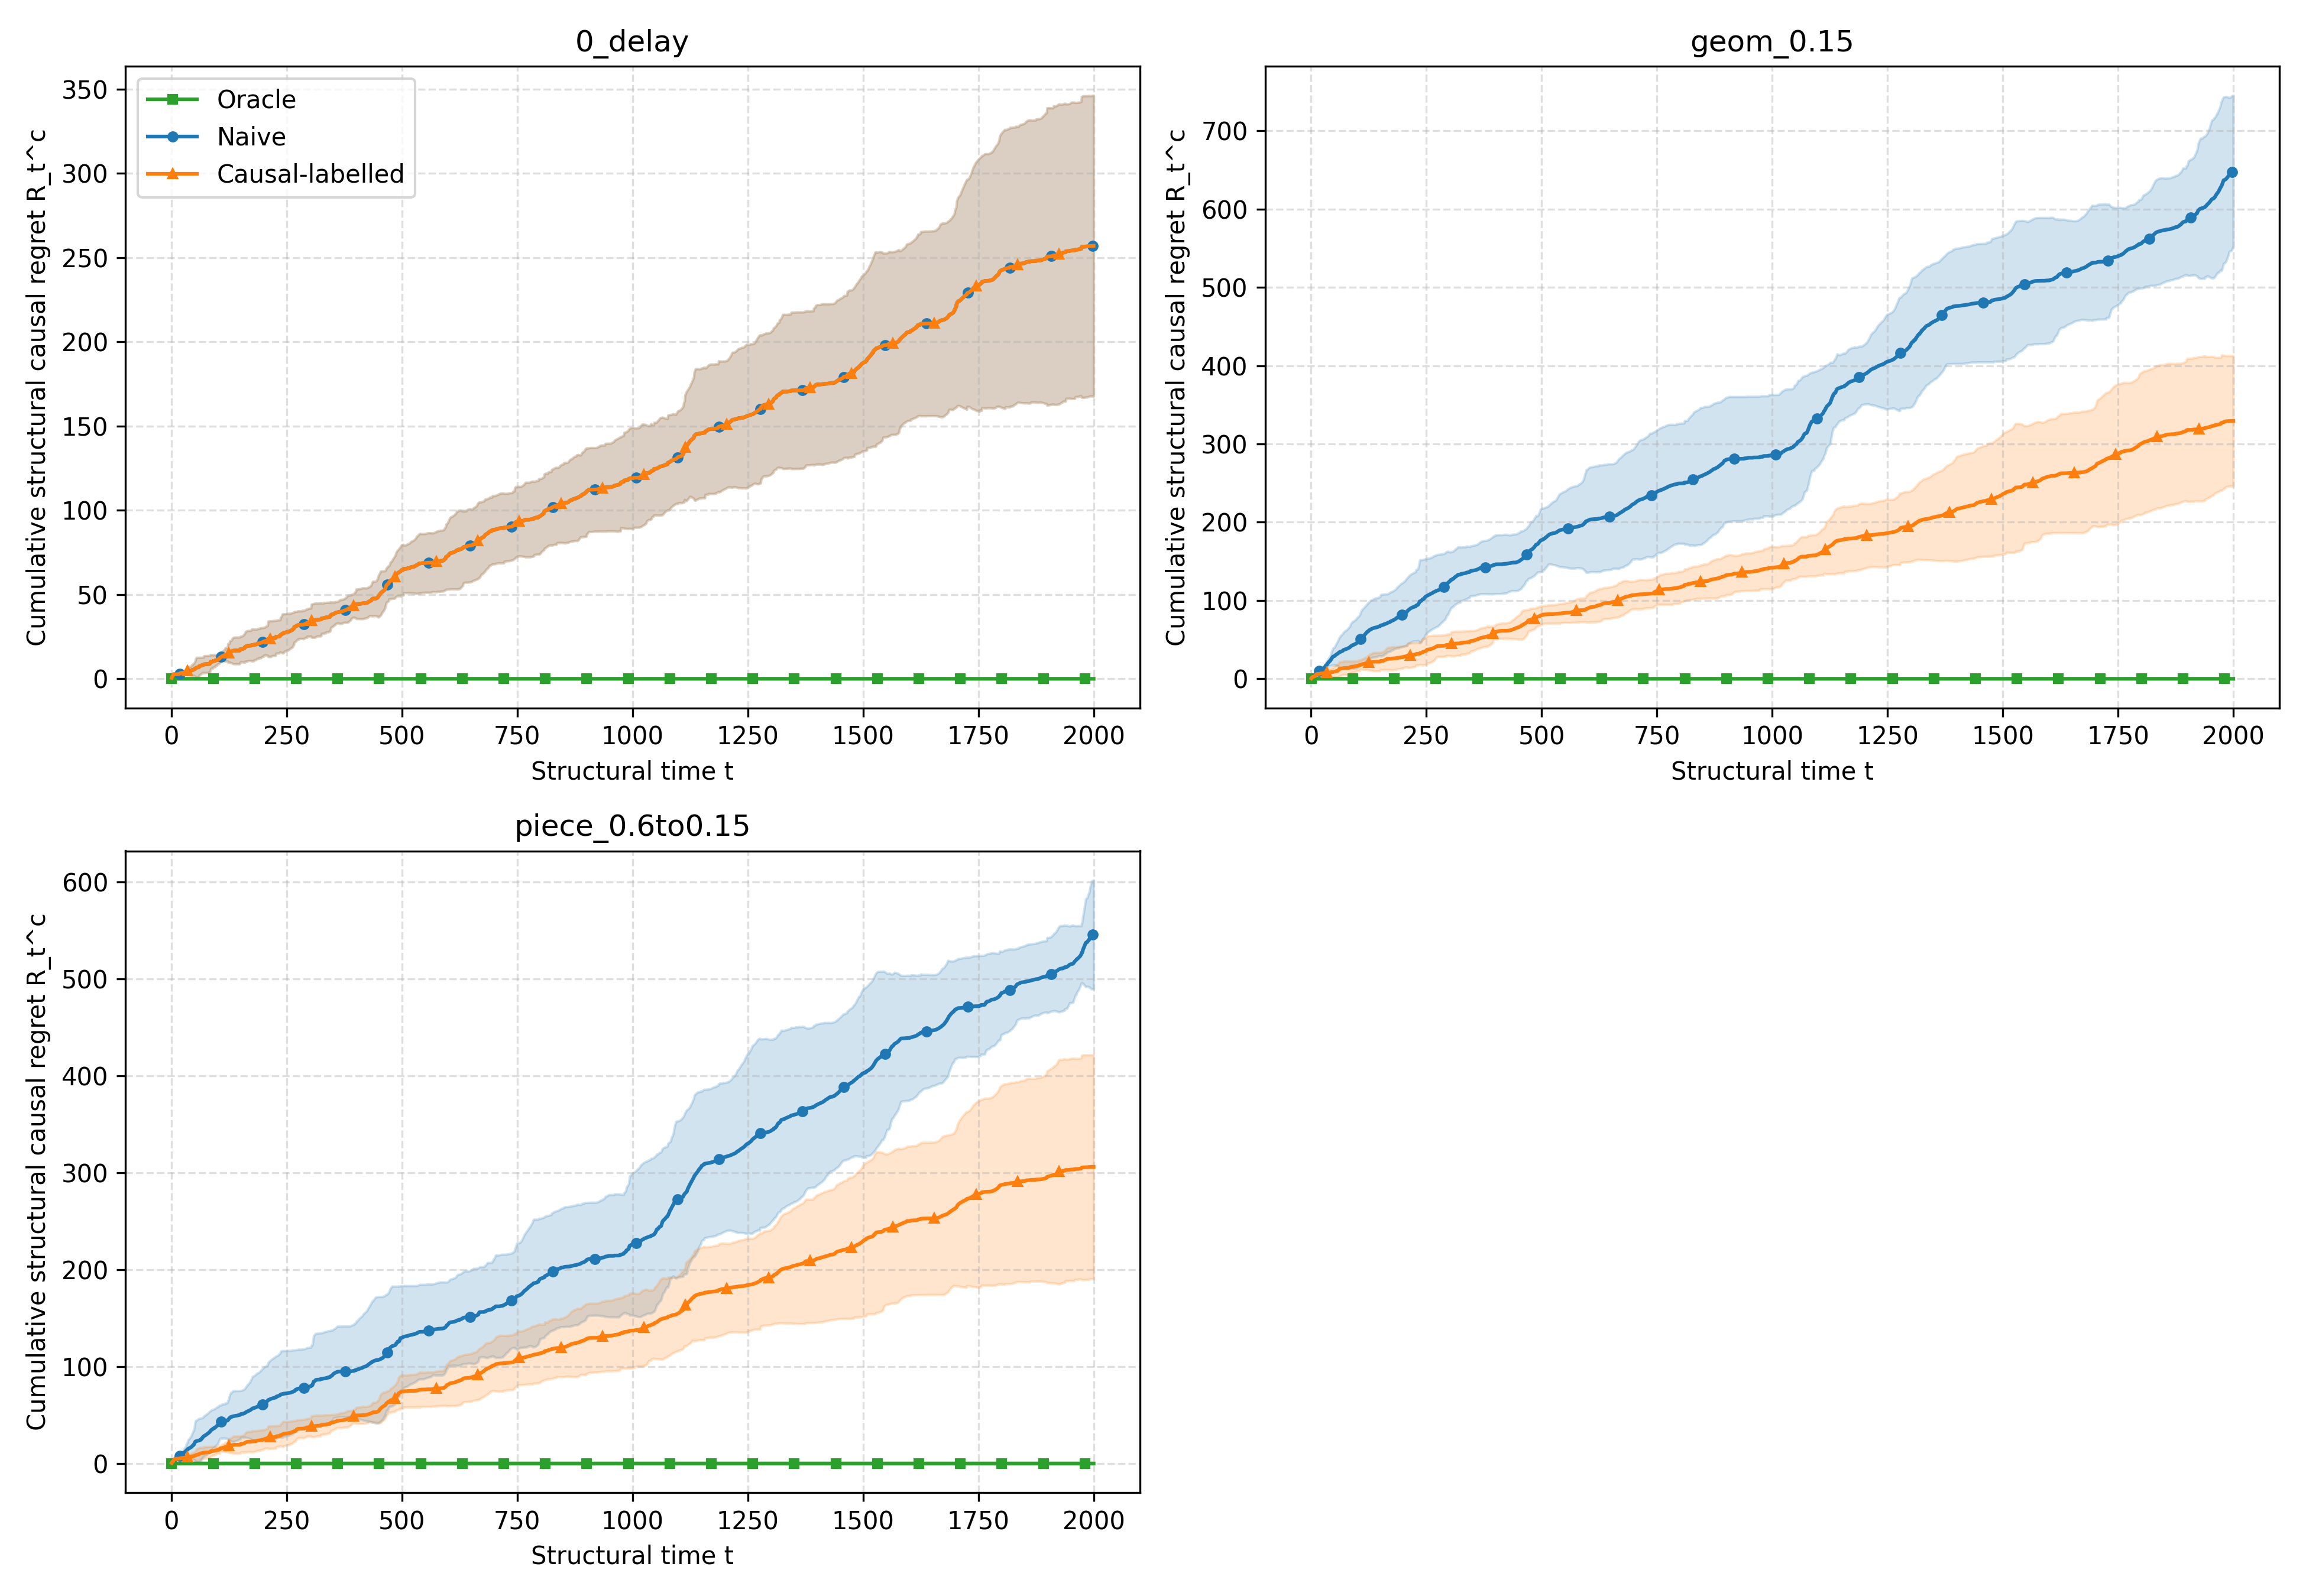

In [3]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)


In [4]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

logs = find_files(['runlogs/*','outputs/**/logs/*','*.log','outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size/1024, 1)} for p in logs[:30]]
display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))


Found `8` runlog/check records.

,path,size_kb
0,outputs/fast/logs/config_snapshot.yaml,0.4
1,outputs/fast/logs/method_registry.csv,0.4
2,outputs/fast/logs/run_manifest.csv,5.8
3,outputs/fast/logs/run_metadata.json,0.5
4,outputs/full/logs/config_snapshot.yaml,0.5
5,outputs/full/logs/method_registry.csv,0.4
6,outputs/full/logs/run_manifest.csv,57.0
7,outputs/full/logs/run_metadata.json,0.7


This notebook only reads existing outputs; no experiment entrypoint was executed.